# Exploration initiale des données DVF du Rhône — 2025

## Objectifs

- Charger les données DVF avec Pandas
- Comprendre la structure du fichier
- Identifier les colonnes importantes
- Étudier les types de biens disponibles
- Repérer les valeurs manquantes et les anomalies potentielles

In [2]:
from pathlib import Path

import pandas as pd


pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

In [3]:
racine_projet = Path.cwd()

if racine_projet.name == "notebooks":
    racine_projet = racine_projet.parent

chemin_dvf = (
    racine_projet
    / "data"
    / "raw"
    / "dvf"
    / "2025"
    / "69.csv.gz"
)

print("Racine du projet :", racine_projet)
print("Chemin du fichier :", chemin_dvf)
print("Le fichier existe :", chemin_dvf.exists())

Racine du projet : C:\Users\henri\Documents\french-real-estate-intelligence
Chemin du fichier : C:\Users\henri\Documents\french-real-estate-intelligence\data\raw\dvf\2025\69.csv.gz
Le fichier existe : True


In [4]:
dvf = pd.read_csv(
    chemin_dvf,
    low_memory=False,
)

print("Chargement terminé.")

Chargement terminé.


In [5]:
nombre_lignes, nombre_colonnes = dvf.shape

print(f"Nombre de lignes : {nombre_lignes:,}")
print(f"Nombre de colonnes : {nombre_colonnes}")

Nombre de lignes : 84,920
Nombre de colonnes : 40


In [6]:
dvf.head()

,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,adresse_numero,adresse_suffixe,adresse_nom_voie,adresse_code_voie,code_postal,code_commune,nom_commune,code_departement,ancien_code_commune,ancien_nom_commune,id_parcelle,ancien_id_parcelle,numero_volume,lot1_numero,lot1_surface_carrez,lot2_numero,lot2_surface_carrez,lot3_numero,lot3_surface_carrez,lot4_numero,lot4_surface_carrez,lot5_numero,lot5_surface_carrez,nombre_lots,code_type_local,type_local,surface_reelle_bati,nombre_pieces_principales,code_nature_culture,nature_culture,code_nature_culture_speciale,nature_culture_speciale,surface_terrain,longitude,latitude
0,2025-858859,2025-01-03,1,Vente,225000.00,86.0,NaN,RUE DES COLLONGES,0290,69230.0,69204,Saint-Genis-Laval,69,NaN,NaN,69204000BH0010,NaN,NaN,16,73.05,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2.0,Appartement,80.0,4.0,NaN,NaN,NaN,NaN,NaN,4.807429,45.692297
1,2025-858859,2025-01-03,1,Vente,225000.00,86.0,NaN,RUE DES COLLONGES,0290,69230.0,69204,Saint-Genis-Laval,69,NaN,NaN,69204000BH0010,NaN,NaN,16,73.05,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3.0,Dépendance,NaN,0.0,NaN,NaN,NaN,NaN,NaN,4.807429,45.692297
2,2025-858859,2025-01-03,1,Vente,225000.00,86.0,NaN,RUE DES COLLONGES,0290,69230.0,69204,Saint-Genis-Laval,69,NaN,NaN,69204000BH0010,NaN,NaN,48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3.0,Dépendance,NaN,0.0,NaN,NaN,NaN,NaN,NaN,4.807429,45.692297
3,2025-858860,2025-01-06,1,Vente,202256.48,20.0,NaN,RUE DE FRANCHE COMTE,0460,69110.0,69202,Sainte-Foy-lès-Lyon,69,NaN,NaN,69202000AH0121,NaN,NaN,470,61.41,484.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3.0,Dépendance,NaN,0.0,NaN,NaN,NaN,NaN,NaN,4.804768,45.747582
4,2025-858860,2025-01-06,1,Vente,202256.48,20.0,NaN,RUE DE FRANCHE COMTE,0460,69110.0,69202,Sainte-Foy-lès-Lyon,69,NaN,NaN,69202000AH0121,NaN,NaN,470,61.41,484.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2.0,Appartement,66.0,3.0,NaN,NaN,NaN,NaN,NaN,4.804768,45.747582


In [7]:
dvf.info()

<class 'pandas.DataFrame'>
RangeIndex: 84920 entries, 0 to 84919
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_mutation                   84920 non-null  str    
 1   date_mutation                 84920 non-null  str    
 2   numero_disposition            84920 non-null  int64  
 3   nature_mutation               84920 non-null  str    
 4   valeur_fonciere               84307 non-null  float64
 5   adresse_numero                70464 non-null  float64
 6   adresse_suffixe               4946 non-null   str    
 7   adresse_nom_voie              84277 non-null  str    
 8   adresse_code_voie             84277 non-null  str    
 9   code_postal                   84277 non-null  float64
 10  code_commune                  84920 non-null  int64  
 11  nom_commune                   84920 non-null  str    
 12  code_departement              84920 non-null  int64  
 13  ancien_code_

In [8]:
dvf["type_local"].value_counts(dropna=False)

type_local
Dépendance                                  33210
Appartement                                 20426
NaN                                         17887
Maison                                       7983
Local industriel. commercial ou assimilé     5414
Name: count, dtype: int64

## Analyse de la granularité des données

Une ligne DVF ne représente pas nécessairement une transaction complète.
Une mutation peut contenir plusieurs locaux : appartement, maison,
dépendance ou local commercial.

Nous devons donc étudier les mutations avant de construire une table
contenant une ligne par vente d'appartement.

In [9]:
nombre_lignes = len(dvf)
nombre_mutations = dvf["id_mutation"].nunique()
moyenne_lignes = nombre_lignes / nombre_mutations

print(f"Nombre de lignes : {nombre_lignes:,}")
print(f"Nombre de mutations uniques : {nombre_mutations:,}")
print(f"Nombre moyen de lignes par mutation : {moyenne_lignes:.2f}")


Nombre de lignes : 84,920
Nombre de mutations uniques : 32,423
Nombre moyen de lignes par mutation : 2.62


In [10]:
lignes_par_mutation = dvf.groupby("id_mutation").size()

lignes_par_mutation.describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

count    32423.000000
mean         2.619128
std          8.616397
min          1.000000
50%          2.000000
75%          3.000000
90%          4.000000
95%          5.000000
99%         12.000000
max       1195.000000
dtype: float64

In [11]:
lignes_par_mutation.value_counts().sort_index().head(15)

1     10169
2     11597
3      6251
4      2138
5       726
6       457
7       244
8       180
9       143
10       81
11       62
12       51
13       33
14       37
15       24
Name: count, dtype: int64

In [12]:
colonnes_exemple = [
    "id_mutation",
    "date_mutation",
    "valeur_fonciere",
    "nom_commune",
    "type_local",
    "surface_reelle_bati",
    "lot1_surface_carrez",
    "nombre_lots",
]

dvf.loc[
    dvf["id_mutation"] == "2025-858859",
    colonnes_exemple,
]

,id_mutation,date_mutation,valeur_fonciere,nom_commune,type_local,surface_reelle_bati,lot1_surface_carrez,nombre_lots
0,2025-858859,2025-01-03,225000.0,Saint-Genis-Laval,Appartement,80.0,73.05,2
1,2025-858859,2025-01-03,225000.0,Saint-Genis-Laval,Dépendance,NaN,73.05,2
2,2025-858859,2025-01-03,225000.0,Saint-Genis-Laval,Dépendance,NaN,NaN,1


In [13]:
dvf["nature_mutation"].value_counts(dropna=False)

nature_mutation
Vente                                 79031
Vente en l'état futur d'achèvement     5213
Echange                                 501
Adjudication                            107
Vente terrain à bâtir                    46
Expropriation                            22
Name: count, dtype: int64

In [14]:
communes_autour_de_lyon = (
    dvf.loc[
        dvf["nom_commune"].str.contains(
            "Lyon|Villeurbanne",
            case=False,
            na=False,
        ),
        ["code_commune", "nom_commune"],
    ]
    .drop_duplicates()
    .sort_values(["nom_commune", "code_commune"])
)

communes_autour_de_lyon

,code_commune,nom_commune
203,69381,Lyon 1er Arrondissement
214,69382,Lyon 2e Arrondissement
47977,69383,Lyon 3e Arrondissement
95,69384,Lyon 4e Arrondissement
45,69385,Lyon 5e Arrondissement
48049,69386,Lyon 6e Arrondissement
47951,69387,Lyon 7e Arrondissement
48007,69388,Lyon 8e Arrondissement
82,69389,Lyon 9e Arrondissement
3,69202,Sainte-Foy-lès-Lyon


## Construction de l'échantillon d'appartements

Pour construire une table adaptée à la valorisation immobilière, nous
conservons les mutations respectant les règles suivantes :

- mutation de nature « Vente » ;
- bien situé dans un arrondissement de Lyon ou à Villeurbanne ;
- présence d'exactement un appartement ;
- absence de maison et de local commercial dans la mutation ;
- présence éventuelle de dépendances.

Cette sélection vise à exclure les ventes en bloc et les mutations mixtes.
Le prix peut néanmoins inclure une cave ou un stationnement, car DVF ne
permet pas de décomposer leur valeur.

In [15]:
dvf["date_mutation"] = pd.to_datetime(
    dvf["date_mutation"],
    errors="coerce",
)

print(dvf["date_mutation"].dtype)
print("Dates invalides :", dvf["date_mutation"].isna().sum())

datetime64[us]
Dates invalides : 0


In [16]:
codes_lyon = list(range(69381, 69390))
code_villeurbanne = 69266

codes_communes_cibles = codes_lyon + [code_villeurbanne]

dvf_zone = dvf.loc[
    dvf["code_commune"].isin(codes_communes_cibles)
    & dvf["nature_mutation"].eq("Vente")
].copy()

print(f"Nombre de lignes dans la zone : {len(dvf_zone):,}")
print(
    "Nombre de mutations dans la zone :",
    f"{dvf_zone['id_mutation'].nunique():,}",
)

Nombre de lignes dans la zone : 27,475
Nombre de mutations dans la zone : 11,529


In [17]:
(
    dvf_zone.groupby("nom_commune")["id_mutation"]
    .nunique()
    .sort_values(ascending=False)
)

nom_commune
Villeurbanne               2520
Lyon 3e Arrondissement     1855
Lyon 7e Arrondissement     1559
Lyon 8e Arrondissement     1226
Lyon 6e Arrondissement      920
Lyon 9e Arrondissement      864
Lyon 5e Arrondissement      754
Lyon 4e Arrondissement      684
Lyon 2e Arrondissement      626
Lyon 1er Arrondissement     530
Name: id_mutation, dtype: int64

In [19]:
resume_mutations = (
    dvf_zone.groupby("id_mutation")
    .agg(
        nombre_lignes=("id_mutation", "size"),
        nombre_appartements=(
            "type_local",
            lambda serie: serie.eq("Appartement").sum(),
        ),
        nombre_maisons=(
            "type_local",
            lambda serie: serie.eq("Maison").sum(),
        ),
        nombre_dependances=(
            "type_local",
            lambda serie: serie.eq("Dépendance").sum(),
        ),
        nombre_locaux_activite=(
            "type_local",
            lambda serie: serie.eq(
                "Local industriel. commercial ou assimilé"
            ).sum(),
        ),
        nombre_lignes_sans_type=(
            "type_local",
            lambda serie: serie.isna().sum(),
        ),
    )
    .reset_index()
)

resume_mutations.head()

,id_mutation,nombre_lignes,nombre_appartements,nombre_maisons,nombre_dependances,nombre_locaux_activite,nombre_lignes_sans_type
0,2025-858878,3,1,0,2,0,0
1,2025-858892,2,1,0,1,0,0
2,2025-858896,1,0,0,0,1,0
3,2025-858939,2,1,0,1,0,0
4,2025-858943,3,1,0,2,0,0


In [20]:
appartements = (
    dvf_zone.loc[
        dvf_zone["type_local"].eq("Appartement")
    ]
    .merge(
        resume_mutations,
        on="id_mutation",
        how="left",
        validate="many_to_one",
    )
)

print(f"Lignes d'appartements avant sélection : {len(appartements):,}")

Lignes d'appartements avant sélection : 10,401


In [21]:
appartements_simples = appartements.loc[
    appartements["nombre_appartements"].eq(1)
    & appartements["nombre_maisons"].eq(0)
    & appartements["nombre_locaux_activite"].eq(0)
].copy()

print(
    "Ventes simples d'appartements :",
    f"{len(appartements_simples):,}",
)

Ventes simples d'appartements : 8,585


In [22]:
assert appartements_simples["id_mutation"].is_unique

print("Chaque ligne correspond à une mutation unique.")

Chaque ligne correspond à une mutation unique.


In [23]:
colonnes_essentielles = [
    "valeur_fonciere",
    "surface_reelle_bati",
    "lot1_surface_carrez",
    "nombre_pieces_principales",
    "longitude",
    "latitude",
]

taux_manquants = (
    appartements_simples[colonnes_essentielles]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
    .rename("pourcentage_manquant")
)

taux_manquants

lot1_surface_carrez          40.10
valeur_fonciere               0.03
latitude                      0.01
longitude                     0.01
surface_reelle_bati           0.00
nombre_pieces_principales     0.00
Name: pourcentage_manquant, dtype: float64

## Construction du prix au mètre carré

La surface réelle bâtie est utilisée comme mesure principale de surface,
car elle est disponible pour l'ensemble des ventes sélectionnées.

Le prix au mètre carré est calculé par :

\[
\text{prix au m²} =
\frac{\text{valeur foncière}}{\text{surface réelle bâtie}}
\]

La valeur foncière peut inclure des dépendances telles qu'une cave ou un
stationnement. Le prix au mètre carré doit donc être interprété comme un
indicateur de la mutation complète et non comme une mesure parfaitement
isolée de l'appartement.

In [25]:
masque_validite = (
    appartements_simples["valeur_fonciere"].notna()
    & appartements_simples["valeur_fonciere"].gt(0)
    & appartements_simples["surface_reelle_bati"].gt(0)
    & appartements_simples["longitude"].notna()
    & appartements_simples["latitude"].notna()
)

appartements_valides = appartements_simples.loc[
    masque_validite
].copy()

nombre_supprime = len(appartements_simples) - len(appartements_valides)

print(
    f"Observations avant vérification : "
    f"{len(appartements_simples):,}"
)
print(
    f"Observations après vérification : "
    f"{len(appartements_valides):,}"
)
print(f"Observations supprimées : {nombre_supprime:,}")

Observations avant vérification : 8,585
Observations après vérification : 8,581
Observations supprimées : 4


In [26]:
appartements_valides["prix_m2"] = (
    appartements_valides["valeur_fonciere"]
    / appartements_valides["surface_reelle_bati"]
)

In [27]:
colonnes_prix = [
    "id_mutation",
    "date_mutation",
    "nom_commune",
    "valeur_fonciere",
    "surface_reelle_bati",
    "nombre_pieces_principales",
    "nombre_dependances",
    "prix_m2",
]

appartements_valides[colonnes_prix].head(10)

,id_mutation,date_mutation,nom_commune,valeur_fonciere,surface_reelle_bati,nombre_pieces_principales,nombre_dependances,prix_m2
0,2025-858878,2025-01-06,Lyon 5e Arrondissement,143700.0,34.0,1.0,2,4226.470588
1,2025-858892,2025-01-09,Lyon 9e Arrondissement,214500.0,48.0,2.0,1,4468.750000
2,2025-858939,2025-01-08,Lyon 5e Arrondissement,166550.0,83.0,5.0,1,2006.626506
3,2025-858943,2025-01-13,Lyon 1er Arrondissement,285100.0,46.0,1.0,2,6197.826087
4,2025-858948,2025-01-16,Lyon 2e Arrondissement,1000.0,26.0,1.0,1,38.461538
5,2025-858967,2025-01-13,Lyon 5e Arrondissement,312700.0,89.0,4.0,2,3513.483146
6,2025-858970,2025-01-15,Lyon 9e Arrondissement,333700.0,90.0,4.0,2,3707.777778
7,2025-858973,2025-01-06,Lyon 4e Arrondissement,412000.0,86.0,3.0,1,4790.697674
8,2025-858976,2025-01-06,Lyon 2e Arrondissement,325000.0,44.0,2.0,2,7386.363636
9,2025-858980,2025-01-06,Lyon 9e Arrondissement,235550.0,71.0,3.0,0,3317.605634


In [29]:
statistiques_prix = (
    appartements_valides[
        [
            "valeur_fonciere",
            "surface_reelle_bati",
            "nombre_pieces_principales",
            "prix_m2",
        ]
    ]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )
    .T
    .round(2)
)

statistiques_prix

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
valeur_fonciere,8581.0,265644.78,166745.56,1.0,51478.40,91400.00,161400.00,230000.00,326450.00,553000.00,845705.20,3087000.00
surface_reelle_bati,8581.0,63.45,30.71,8.0,17.00,20.00,42.00,62.00,80.00,117.00,165.00,305.00
nombre_pieces_principales,8581.0,2.71,1.28,0.0,1.00,1.00,2.00,3.00,4.00,5.00,6.00,9.00
prix_m2,8581.0,4275.39,1364.68,0.0,1218.52,2281.75,3423.91,4238.64,5048.54,6428.57,7923.11,24456.52


In [30]:
appartements_valides.nsmallest(
    10,
    "prix_m2",
)[colonnes_prix]

,id_mutation,date_mutation,nom_commune,valeur_fonciere,surface_reelle_bati,nombre_pieces_principales,nombre_dependances,prix_m2
85,2025-859579,2025-01-28,Lyon 2e Arrondissement,1.00,224.0,5.0,3,0.004464
4784,2025-880071,2025-04-03,Lyon 6e Arrondissement,1.00,103.0,4.0,0,0.009709
2387,2025-872712,2025-10-20,Lyon 4e Arrondissement,1.00,84.0,4.0,0,0.011905
1756,2025-869385,2025-08-01,Lyon 4e Arrondissement,1.00,13.0,1.0,0,0.076923
718,2025-863341,2025-04-01,Lyon 2e Arrondissement,100.00,180.0,7.0,2,0.555556
720,2025-863343,2025-04-01,Lyon 2e Arrondissement,100.00,180.0,7.0,2,0.555556
731,2025-863375,2025-04-01,Lyon 2e Arrondissement,100.00,180.0,7.0,2,0.555556
719,2025-863342,2025-04-01,Lyon 2e Arrondissement,1100.00,180.0,7.0,2,6.111111
8254,2025-886847,2025-09-16,Lyon 3e Arrondissement,1371.95,105.0,4.0,0,13.066190
1816,2025-869731,2025-08-27,Lyon 1er Arrondissement,800.00,58.0,3.0,2,13.793103


In [31]:
appartements_valides.nlargest(
    10,
    "prix_m2",
)[colonnes_prix]

,id_mutation,date_mutation,nom_commune,valeur_fonciere,surface_reelle_bati,nombre_pieces_principales,nombre_dependances,prix_m2
1594,2025-868369,2025-07-18,Lyon 5e Arrondissement,2250000.0,92.0,4.0,1,24456.521739
10155,2025-890640,2025-12-31,Villeurbanne,910000.0,43.0,1.0,1,21162.790698
3398,2025-877306,2025-01-08,Lyon 6e Arrondissement,840000.0,50.0,2.0,1,16800.000000
727,2025-863364,2025-03-28,Lyon 5e Arrondissement,2243000.0,138.0,6.0,1,16253.623188
8111,2025-886557,2025-09-26,Lyon 6e Arrondissement,885000.0,64.0,4.0,1,13828.125000
2268,2025-871948,2025-09-30,Lyon 1er Arrondissement,305000.0,23.0,1.0,0,13260.869565
241,2025-860565,2025-02-04,Lyon 5e Arrondissement,384100.0,30.0,2.0,0,12803.333333
1361,2025-866897,2025-06-27,Lyon 5e Arrondissement,1756300.0,152.0,5.0,3,11554.605263
208,2025-860378,2025-02-14,Lyon 4e Arrondissement,866365.0,80.0,4.0,2,10829.562500
9288,2025-888986,2025-11-04,Lyon 6e Arrondissement,1880129.0,175.0,5.0,3,10743.594286


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

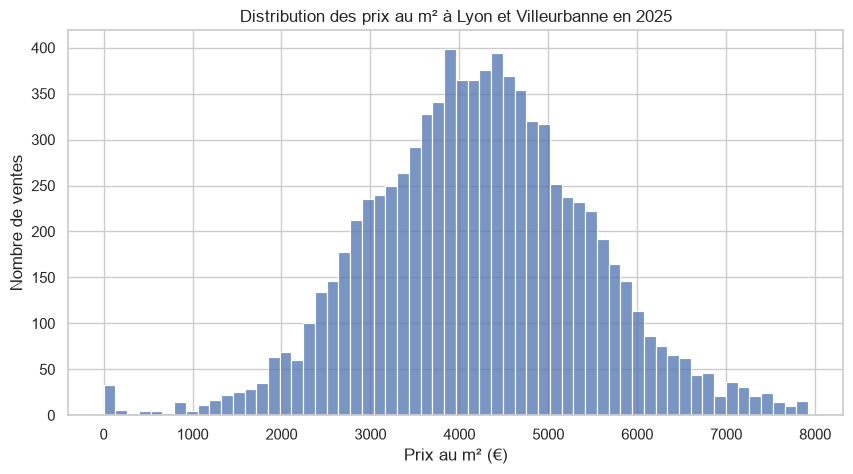

In [33]:
limite_affichage = appartements_valides["prix_m2"].quantile(0.99)

figure, axe = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=appartements_valides.loc[
        appartements_valides["prix_m2"] <= limite_affichage
    ],
    x="prix_m2",
    bins=60,
    ax=axe,
)

axe.set_title(
    "Distribution des prix au m² à Lyon et Villeurbanne en 2025"
)
axe.set_xlabel("Prix au m² (€)")
axe.set_ylabel("Nombre de ventes")

plt.show()

## Traitement des valeurs manifestement atypiques

Les valeurs extrêmes ne sont pas automatiquement considérées comme
fausses. Certaines peuvent correspondre à des appartements haut de gamme
ou à des transactions particulières.

Pour construire l'échantillon de modélisation, nous appliquons uniquement
des règles larges de plausibilité :

- prix au m² compris entre 500 et 15 000 euros ;
- au moins une pièce principale.

Les observations écartées sont conservées séparément. Ces règles constituent
un nettoyage initial et non notre méthode finale de détection d'anomalies.


In [35]:
SEUIL_PRIX_M2_MIN = 500
SEUIL_PRIX_M2_MAX = 15_000

appartements_valides["prix_m2_hors_plage"] = ~(
    appartements_valides["prix_m2"].between(
        SEUIL_PRIX_M2_MIN,
        SEUIL_PRIX_M2_MAX,
    )
)

appartements_valides["nombre_pieces_invalide"] = (
    appartements_valides["nombre_pieces_principales"].lt(1)
)

In [37]:
masque_exclusion = (
    appartements_valides["prix_m2_hors_plage"]
    | appartements_valides["nombre_pieces_invalide"]
)

In [38]:
bilan_nettoyage = pd.Series(
    {
        "observations_initiales": len(appartements_valides),
        "prix_m2_hors_plage": int(
            appartements_valides["prix_m2_hors_plage"].sum()
        ),
        "nombre_pieces_invalide": int(
            appartements_valides["nombre_pieces_invalide"].sum()
        ),
        "observations_exclues": int(masque_exclusion.sum()),
        "observations_conservees": int((~masque_exclusion).sum()),
    },
    name="nombre_observations",
)

bilan_nettoyage

observations_initiales     8581
prix_m2_hors_plage           50
nombre_pieces_invalide       19
observations_exclues         69
observations_conservees    8512
Name: nombre_observations, dtype: int64

In [39]:
appartements_anomalies_regles = appartements_valides.loc[
    masque_exclusion
].copy()

appartements_modelisation = appartements_valides.loc[
    ~masque_exclusion
].copy()

print(
    "Transactions conservées pour la modélisation :",
    f"{len(appartements_modelisation):,}",
)
print(
    "Transactions signalées par les règles :",
    f"{len(appartements_anomalies_regles):,}",
)

Transactions conservées pour la modélisation : 8,512
Transactions signalées par les règles : 69


In [40]:
colonnes_anomalies = colonnes_prix + [
    "prix_m2_hors_plage",
    "nombre_pieces_invalide",
]

appartements_anomalies_regles.sort_values(
    "prix_m2"
)[colonnes_anomalies].head(20)

,id_mutation,date_mutation,nom_commune,valeur_fonciere,surface_reelle_bati,nombre_pieces_principales,nombre_dependances,prix_m2,prix_m2_hors_plage,nombre_pieces_invalide
85,2025-859579,2025-01-28,Lyon 2e Arrondissement,1.00,224.0,5.0,3,0.004464,True,False
4784,2025-880071,2025-04-03,Lyon 6e Arrondissement,1.00,103.0,4.0,0,0.009709,True,False
2387,2025-872712,2025-10-20,Lyon 4e Arrondissement,1.00,84.0,4.0,0,0.011905,True,False
1756,2025-869385,2025-08-01,Lyon 4e Arrondissement,1.00,13.0,1.0,0,0.076923,True,False
720,2025-863343,2025-04-01,Lyon 2e Arrondissement,100.00,180.0,7.0,2,0.555556,True,False
718,2025-863341,2025-04-01,Lyon 2e Arrondissement,100.00,180.0,7.0,2,0.555556,True,False
731,2025-863375,2025-04-01,Lyon 2e Arrondissement,100.00,180.0,7.0,2,0.555556,True,False
719,2025-863342,2025-04-01,Lyon 2e Arrondissement,1100.00,180.0,7.0,2,6.111111,True,False
8254,2025-886847,2025-09-16,Lyon 3e Arrondissement,1371.95,105.0,4.0,0,13.066190,True,False
1816,2025-869731,2025-08-27,Lyon 1er Arrondissement,800.00,58.0,3.0,2,13.793103,True,False


In [41]:
appartements_anomalies_regles.sort_values(
    "prix_m2",
    ascending=False,
)[colonnes_anomalies].head(20)

,id_mutation,date_mutation,nom_commune,valeur_fonciere,surface_reelle_bati,nombre_pieces_principales,nombre_dependances,prix_m2,prix_m2_hors_plage,nombre_pieces_invalide
1594,2025-868369,2025-07-18,Lyon 5e Arrondissement,2250000.0,92.0,4.0,1,24456.521739,True,False
10155,2025-890640,2025-12-31,Villeurbanne,910000.0,43.0,1.0,1,21162.790698,True,False
3398,2025-877306,2025-01-08,Lyon 6e Arrondissement,840000.0,50.0,2.0,1,16800.000000,True,False
727,2025-863364,2025-03-28,Lyon 5e Arrondissement,2243000.0,138.0,6.0,1,16253.623188,True,False
2074,2025-871093,2025-09-17,Lyon 5e Arrondissement,118750.0,13.0,0.0,0,9134.615385,False,True
2346,2025-872404,2025-10-03,Lyon 4e Arrondissement,210000.0,28.0,0.0,0,7500.000000,False,True
5335,2025-881129,2025-04-24,Villeurbanne,109000.0,15.0,0.0,0,7266.666667,False,True
10270,2025-890949,2025-12-23,Lyon 7e Arrondissement,106500.0,15.0,0.0,1,7100.000000,False,True
7979,2025-886309,2025-09-01,Lyon 7e Arrondissement,135000.0,20.0,0.0,0,6750.000000,False,True
7802,2025-885966,2025-09-08,Lyon 3e Arrondissement,107000.0,16.0,0.0,0,6687.500000,False,True


In [42]:
statistiques_zones = (
    appartements_modelisation.groupby("nom_commune")
    .agg(
        nombre_ventes=("prix_m2", "size"),
        prix_m2_median=("prix_m2", "median"),
        prix_m2_moyen=("prix_m2", "mean"),
        surface_mediane=("surface_reelle_bati", "median"),
    )
    .round(0)
    .sort_values("prix_m2_median", ascending=False)
)

statistiques_zones

,nombre_ventes,prix_m2_median,prix_m2_moyen,surface_mediane
nom_commune,,,,
Lyon 6e Arrondissement,638,5464.0,5488.0,70.0
Lyon 2e Arrondissement,424,5000.0,5108.0,60.0
Lyon 4e Arrondissement,485,4816.0,4869.0,65.0
Lyon 1er Arrondissement,404,4800.0,4917.0,53.0
Lyon 7e Arrondissement,1221,4500.0,4446.0,54.0
Lyon 3e Arrondissement,1341,4491.0,4530.0,61.0
Lyon 8e Arrondissement,920,3965.0,3989.0,60.0
Lyon 9e Arrondissement,646,3716.0,3706.0,64.0
Lyon 5e Arrondissement,564,3701.0,3902.0,68.0


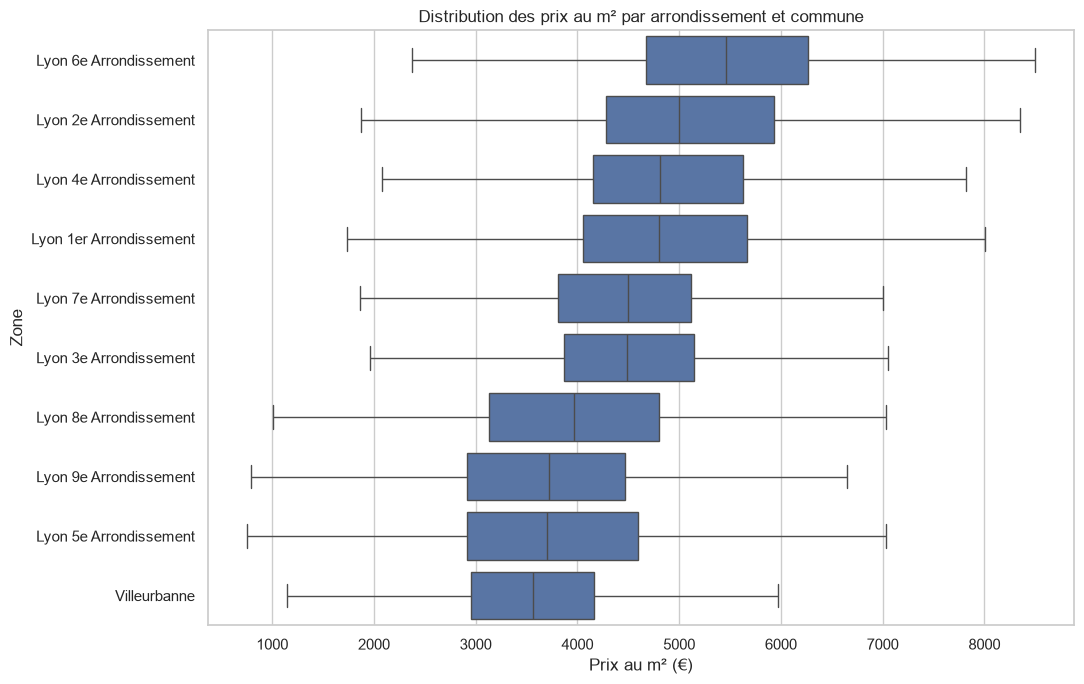

In [43]:
ordre_zones = statistiques_zones.index.tolist()

figure, axe = plt.subplots(figsize=(11, 7))

sns.boxplot(
    data=appartements_modelisation,
    x="prix_m2",
    y="nom_commune",
    order=ordre_zones,
    showfliers=False,
    ax=axe,
)

axe.set_title(
    "Distribution des prix au m² par arrondissement et commune"
)
axe.set_xlabel("Prix au m² (€)")
axe.set_ylabel("Zone")

plt.tight_layout()
plt.show()